In [1]:
!pip install -r requirements.txt

In [28]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import  TfidfVectorizer
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix,  classification_report
from sklearn.svm import LinearSVC

In [29]:
RANDOM_SEED = 42
DATA_PREPR = Path("./data-sources/pre-processed")
csv_files = sorted(DATA_PREPR.glob("data_chunk_*.csv"))

df_list = []
for f in csv_files:
    df_part = pd.read_csv(f)
    df_list.append(df_part)
data = pd.concat(df_list, ignore_index=True)
print(data.shape)
data.head()

(58963, 2)


,text,pls
0,Background\nThis is an update of a review publ...,0
1,Background\nPolycystic ovary syndrome (PCOS) i...,0
2,Background\nDysmenorrhoea is a common gynaecol...,0
3,Background\nDental caries is a sugar‐dependent...,0
4,Background\nOur March 2021 edition of this rev...,0


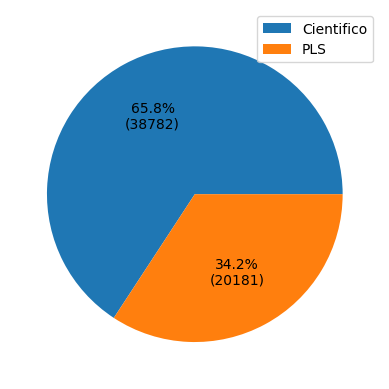

In [31]:
def autopct_format(values):
        def my_format(pct):
            total = sum(values)
            val = int(round(pct*total/100.0))
            return '{:.1f}%\n({v:d})'.format(pct, v=val)
        return my_format

pls_label = {0: 'Cientifico',1: 'PLS'}

df_temp = data.groupby(['pls']).size().to_frame(name='count').reset_index()
df_temp['pls'] = df_temp['pls'].replace(pls_label)

plt.pie(df_temp['count'],autopct=autopct_format(df_temp['count']))
plt.legend(df_temp['pls'])
plt.show()

In [32]:
df_train, df_temp = train_test_split(data, test_size=0.3,random_state=RANDOM_SEED,stratify=data['pls'])
df_test, df_val = train_test_split(df_temp,test_size=0.5, stratify=df_temp['pls'],random_state=RANDOM_SEED)

print(f'Tamaño dataset entrenamiento: {len(df_train)/len(data):.0%}')
print(f'Tamaño dataset validación: {len(df_val)/len(data):.0%}')
print(f'Tamaño dataset test: {len(df_test)/len(data):.0%}')

x_train,y_train = df_train['text'],df_train['pls']
x_test,y_test = df_test['text'],df_test['pls']
x_val,y_val = df_val['text'],df_val['pls']

Tamaño dataset entrenamiento: 70%
Tamaño dataset validación: 15%
Tamaño dataset test: 15%


In [33]:
class TextPreprocessor():

    def clean_light_text(self, text):
        text = re.sub(r'([\(\)"“”‘’!?.,:;()&^%$#@\-_\[\]\*])', r' \1 ', text)
        text = re.sub(r'\n+', ' ', text)
        return text
    
    def tokenize(self, text):
        return text.split()

In [34]:
c_classes = np.unique(y_train)
c_weight=compute_class_weight(class_weight="balanced", classes=c_classes, y=y_train)
dict_weight = {}
for A, B in zip(c_classes, c_weight):
    dict_weight[int(A)] = float(B)

print(dict_weight)


{0: 0.7601944966294618, 1: 1.4608197069441495}


In [35]:
text_processor = TextPreprocessor()
pipeline = Pipeline([
    ('vect', TfidfVectorizer()),
    ('clf',LinearSVC())
    ])

param_grid = { 
    'clf__class_weight': [dict_weight],
    'clf__C':[1],
    'clf__penalty':['l2'],
    'vect__ngram_range':[(1,2)],
    'vect__max_df': [0.8],
    'vect__min_df': [1],
    'vect__preprocessor' : [text_processor.clean_light_text],
    'vect__tokenizer' : [text_processor.tokenize],
    'vect__strip_accents':['ascii'],
    'vect__token_pattern':[None]
    }


# Búsqueda de hiperparámetros con validación cruzada
grid_search = GridSearchCV(pipeline, param_grid=param_grid, cv=5, scoring='f1_macro',verbose=2,n_jobs=3)

# Entrenar el modelo
grid_search.fit(x_train, y_train)

# Imprimir los mejores parámetros encontrados
print("Mejores Hiperparámetros: ", grid_search.best_params_)
print("Mejor puntaje de validación cruzada: {:.5f}".format(grid_search.best_score_))
# Evaluar el modelo con los datos de prueba
y_pred = grid_search.predict(x_test)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END clf__C=1, clf__class_weight={0: 0.7601944966294618, 1: 1.4608197069441495}, clf__penalty=l2, vect__max_df=0.8, vect__min_df=1, vect__ngram_range=(1, 2), vect__preprocessor=<bound method TextPreprocessor.clean_light_text of <__main__.TextPreprocessor object at 0x14ed17f70>>, vect__strip_accents=ascii, vect__token_pattern=None, vect__tokenizer=<bound method TextPreprocessor.tokenize of <__main__.TextPreprocessor object at 0x14ed17f70>>; total time=  24.0s
[CV] END clf__C=1, clf__class_weight={0: 0.7601944966294618, 1: 1.4608197069441495}, clf__penalty=l2, vect__max_df=0.8, vect__min_df=1, vect__ngram_range=(1, 2), vect__preprocessor=<bound method TextPreprocessor.clean_light_text of <__main__.TextPreprocessor object at 0x14b71af70>>, vect__strip_accents=ascii, vect__token_pattern=None, vect__tokenizer=<bound method TextPreprocessor.tokenize of <__main__.TextPreprocessor object at 0x14b71af70>>; total time=  24.1s
[CV] EN

In [37]:
df_results = pd.DataFrame(grid_search.cv_results_)
df_results.sort_values(by='mean_test_score', ascending=False)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clf__C,param_clf__class_weight,param_clf__penalty,param_vect__max_df,param_vect__min_df,param_vect__ngram_range,...,param_vect__tokenizer,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,18.88609,1.372926,3.96041,0.165961,1,"{0: 0.7601944966294618, 1: 1.4608197069441495}",l2,0.8,1,"(1, 2)",...,<bound method TextPreprocessor.tokenize of <__...,"{'clf__C': 1, 'clf__class_weight': {0: 0.76019...",0.999058,0.99879,0.99879,0.99879,0.998924,0.99887,0.000107,1


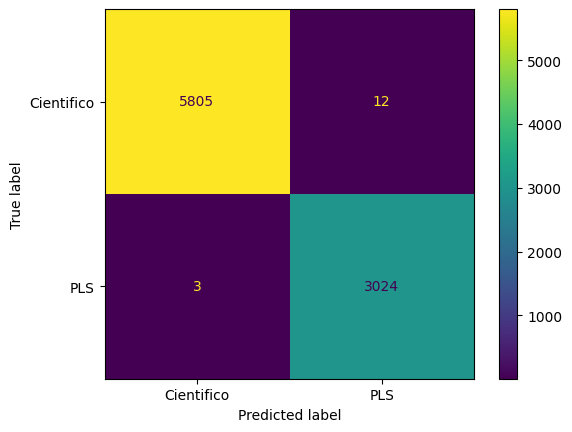

In [ ]:
conf_mtx = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(conf_mtx,display_labels=['Cientifico', 'PLS'])
disp.plot()
plt.show()

In [40]:
print(classification_report(y_test, y_pred,digits=4))

              precision    recall  f1-score   support

           0     0.9995    0.9979    0.9987      5817
           1     0.9960    0.9990    0.9975      3027

    accuracy                         0.9983      8844
   macro avg     0.9978    0.9985    0.9981      8844
weighted avg     0.9983    0.9983    0.9983      8844



In [41]:
y_pred_eval = grid_search.predict(x_val)
print(classification_report(y_val, y_pred_eval,digits=4))

              precision    recall  f1-score   support

           0     0.9995    0.9985    0.9990      5818
           1     0.9970    0.9990    0.9980      3027

    accuracy                         0.9986      8845
   macro avg     0.9983    0.9987    0.9985      8845
weighted avg     0.9986    0.9986    0.9986      8845



In [42]:
print(x_val.iloc[5])
print(f'Valor Original: {y_val.iloc[5]}')
print(f'Valor Predicho: {grid_search.predict(x_val.iloc[[5]])}')

Background
The risk of cytomegalovirus (CMV) infection in solid organ transplant recipients has resulted in the frequent use of prophylaxis with the aim of preventing the clinical syndrome associated with CMV infection. This is an update of a review first published in 2005 and updated in 2008. 
Objectives
To determine the benefits and harms of antiviral medications to prevent CMV disease and all‐cause mortality in solid organ transplant recipients. 
Search methods
We searched MEDLINE, EMBASE and the Cochrane Central Registry of Controlled Trials (CENTRAL) in The Cochrane Library to February 2004 for the first version of this review. The Cochrane Renal Group's specialised register was searched to February 2007 and to July 2011 for the first and current updates of the review without language restriction. 
Selection criteria
We included randomised controlled trials (RCTs) and quasi‐RCTs comparing antiviral medications with placebo or no treatment, comparing different antiviral medications